# 06 - REAL DATA case study: Volve production
Separate from PetroNexa. Units converted from Sm3 with documented factors.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30); pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from og_oip import config
NOTICE = config.SYNTHETIC_NOTICE
print(NOTICE)

All operational, production, financial, maintenance, inventory, sensor and HSE data in this project are synthetic/simulated and created for portfolio demonstration purposes. They do not represent actual operations of a real company.


In [2]:
from og_oip.real_data import volve
daily, monthly = volve.load(); v = volve.analyse(daily, monthly); v["data_quality"]

                                                          check     value
0                                                    daily rows 15,634.00
1                               duplicate (date, wellbore) rows      0.00
2                                  rows with ON_STREAM_HRS > 24     20.00
3                                 rows with negative oil volume      0.00
4                       production rows with missing oil volume      0.00
5                  production rows with missing on-stream hours      0.00
6         production rows with oil > 0 but on-stream hours == 0      1.00
7                   daily-vs-monthly sheet: matched well-months    311.00
8   daily-vs-monthly sheet: well-months with |oil diff| > 1 Sm3      0.00
9                    daily-vs-monthly sheet: max |oil diff| Sm3      0.00
10                 monthly sheet well-months not found in daily    215.00

In [3]:
v["well_summary"][["wellbore","first_date","last_date","cum_oil_bbl","water_cut_pct","uptime_pct_of_calendar_span","oil_share_pct"]]

      wellbore first_date  last_date   cum_oil_bbl  water_cut_pct  uptime_pct_of_calendar_span  oil_share_pct
2    15/9-F-12 2008-02-12 2016-09-17 28,804,873.94          59.87                        86.50          45.63
3    15/9-F-14 2008-02-12 2016-09-17 24,795,899.00          64.37                        83.27          39.28
1    15/9-F-11 2013-07-08 2016-09-17  7,219,752.75          48.73                        92.77          11.44
0   15/9-F-1 C 2014-04-07 2016-04-21  1,117,757.92          53.84                        55.76           1.77
4  15/9-F-15 D 2014-01-12 2016-09-17    934,153.52          26.07                        75.79           1.48
5     15/9-F-5 2016-04-11 2016-09-17    258,892.86          24.74                        77.43           0.41

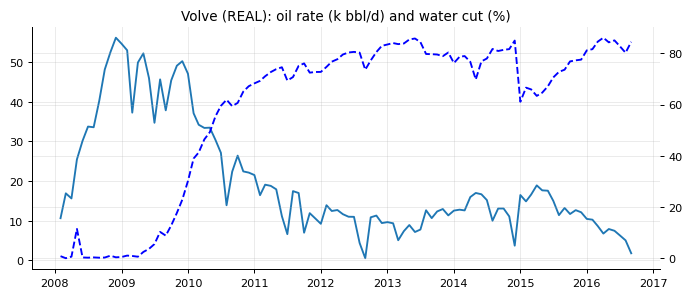

In [4]:
fmn = v["field_monthly"]; fig, ax = plt.subplots(figsize=(9,3.5)); ax.plot(fmn.month, fmn.avg_daily_oil_bbl/1e3); ax2 = ax.twinx(); ax2.plot(fmn.month, fmn.water_cut_pct, "b--")
ax.set_title("Volve (REAL): oil rate (k bbl/d) and water cut (%)"); plt.show()

In [5]:
v["field_decline"], v["yearly"]

(   peak_month  peak_avg_daily_oil_bbl  months_fitted  nominal_annual_decline_pct  r_squared                                               note
0  2008-12-01               56,129.24             94                       19.23       0.42  single exponential fit peak->end; ignores shut...,    year       oil_bbl       gas_mcf     water_bbl  water_cut_pct
0  2008 11,097,584.46  9,077,240.58    147,866.77           1.31
1  2009 16,884,315.90 13,277,691.98  1,459,888.42           7.96
2  2010 10,629,165.96  8,614,963.64 11,872,612.52          52.76
3  2011  5,333,541.25  4,602,218.60 13,778,711.14          72.09
4  2012  3,611,648.72  3,185,691.16 13,268,993.43          78.60
5  2013  3,509,792.79  3,093,136.05 16,204,851.31          82.20
6  2014  4,674,004.92  3,947,896.51 17,083,570.03          78.52
7  2015  5,420,237.86  4,535,249.52 12,641,422.79          69.99
8  2016  1,971,038.14  1,768,176.29  9,893,030.87          83.39)

In [6]:
volve.forecast_backtest(fmn)[1]

                           model      MAE     RMSE  MAPE_pct  mean_bias  origins
0  Damped Holt (trend) smoothing 2,669.53 3,249.12     44.42   1,339.89        4
2             Naive (last value) 2,698.61 3,336.08     46.13   1,604.37        4
3   Simple exponential smoothing 2,761.43 3,331.71     47.24   1,456.61        4
1      Moving average (3 months) 3,003.37 3,533.69     52.00   1,656.06        4

Limits: no maintenance, cost or price data in the file, so no reliability or financial KPIs are derived.